In [40]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST, SRD

In [41]:
file_indices = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
print(file_indices)

rotation = np.round(np.linspace(0.5,1.5,11),1)
rotation = np.append(rotation, [0.1, 0.01, 0.05, 2])
print(rotation)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
[0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3  1.4  1.5  0.1  0.01 0.05
 2.  ]


In [42]:
file_template = "../rotation/output{}.nc"
results = []

In [43]:
for idx in file_indices:
    fname = file_template.format(idx)

    # Ensure file exists
    if not Path(fname).exists():
        print(f"Warning: {fname} not found, skipping.")
        continue

    # Prepare containers for this file/run
    run = {
        "month": [],
        "ice_tot": [], "ice_nhem": [], "ice_shem": [],
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
        "sst_tot": [], "sst_nhem": [], "sst_shem": [],
        "srd_tot": [], "srd_nhem": [], "srd_shem": []
    }
    
    # Open dataset and process
    with xr.open_dataset(fname) as ds:
        ds_crop = ds.sel(time=slice("2001-01-01", "2002-01-01"))
        monthly_data = ds_crop.groupby("time.month")
        months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
        run["month"].append(months)

        for month, data in monthly_data:

            # Whole globe
            ice_frac = SeaIceCalc.ice_frac(data)[0]
            fraction_sm = Habitability.fraction(data, "sm")[0]
            fraction_st = Habitability.fraction(data, "st")[0]
            fraction_tsurf = Habitability.fraction(data, "tsurf")[0]
            sst_tot = SST.temp(data)
            srd_tot = SRD.srd_calc(data)[0]


            run["ice_tot"].append(ice_frac)
            run["sm_tot"].append(fraction_sm)
            run["st_tot"].append(fraction_st)
            run["tsurf_tot"].append(fraction_tsurf)
            run["sst_tot"].append(sst_tot)
            run["srd_tot"].append(srd_tot)

            # Northern hemisphere
            ice_n = SeaIceCalc.ice_frac(data, lat=slice(0,24))[0]
            sm_n = Habitability.fraction(data, "sm", lat=slice(0,24))[0]
            st_n = Habitability.fraction(data, "st", lat=slice(0,24))[0]
            tsurf_n = Habitability.fraction(data, "tsurf", lat=slice(0,24))[0]
            sst_n = SST.temp(data, lat=slice(0,24))
            srd_n = SRD.srd_calc(data, lat=slice(0,24))[0]

            run["ice_nhem"].append(ice_n)
            run["sm_nhem"].append(sm_n)
            run["st_nhem"].append(st_n)
            run["tsurf_nhem"].append(tsurf_n)
            run["sst_nhem"].append(sst_n)
            run["srd_nhem"].append(srd_n)

            # Southern hemisphere
            ice_s = SeaIceCalc.ice_frac(data, lat=slice(24,48))[0]
            sm_s = Habitability.fraction(data, "sm", lat=slice(24,48))[0]
            st_s = Habitability.fraction(data, "st", lat=slice(24,48))[0]
            tsurf_s = Habitability.fraction(data, "tsurf", lat=slice(24,48))[0]
            sst_s = SST.temp(data, lat=slice(24,48))
            srd_s = SRD.srd_calc(data, lat=slice(24,48))[0]
            run["ice_shem"].append(ice_s)
            run["sm_shem"].append(sm_s)
            run["st_shem"].append(st_s)
            run["tsurf_shem"].append(tsurf_s)
            run["sst_shem"].append(sst_s)
            run["srd_shem"].append(srd_s)

    # convert lists to numpy arrays (for math/plotting later)
    for k in run:
        if run[k] is None:
            continue
        if isinstance(run[k], list):
            run[k] = np.array(run[k]) 

    # Store results
    results.append({"file": fname, "data": run})


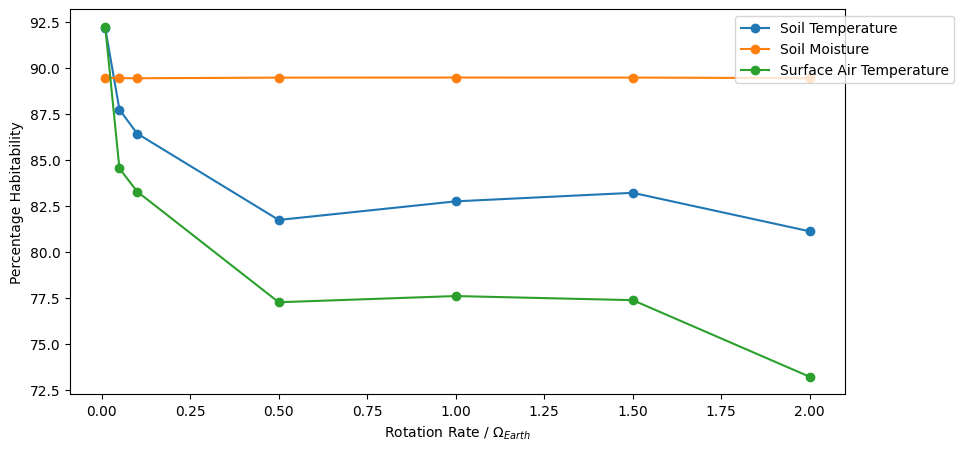

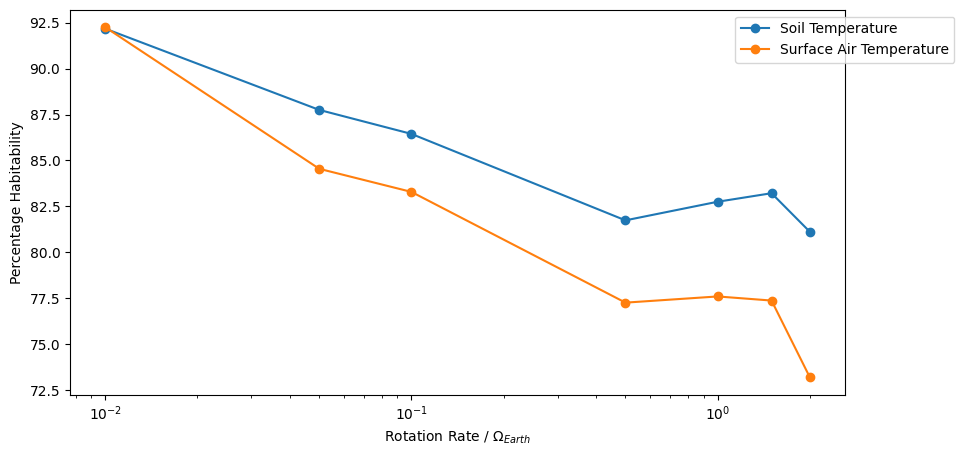

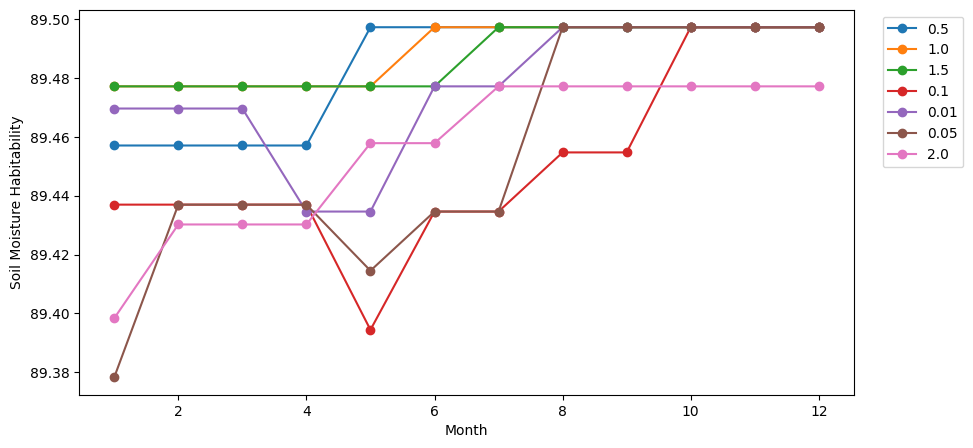

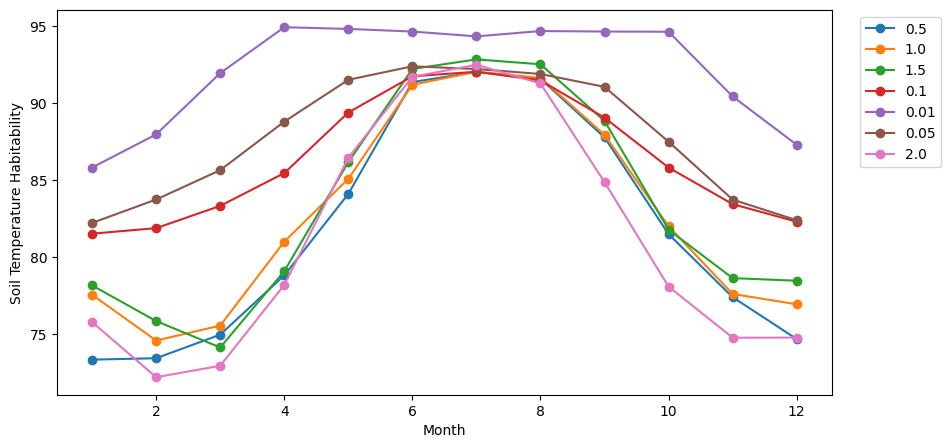

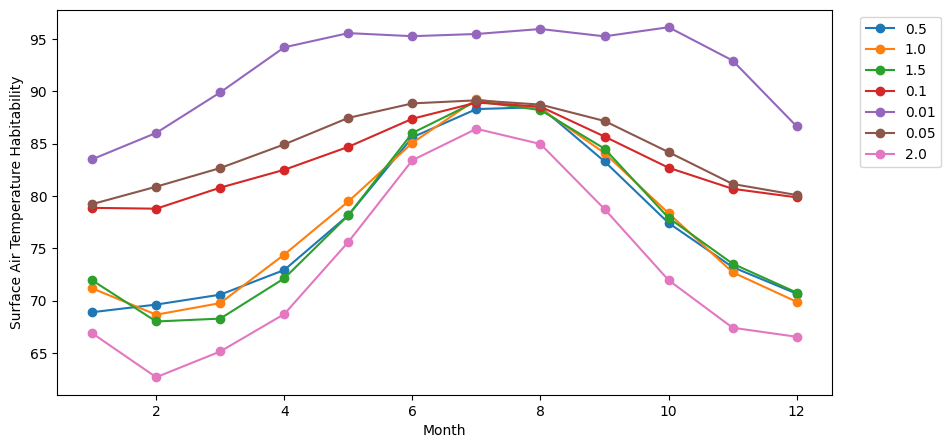

In [99]:
fig = plt.figure(figsize=(10, 5))
y_sm = []
y_st = []
y_tsurf = []
x = []
for r, rot in zip([results[i] for i in [0,5,10,11,12,13,14]], [rotation[i] for i in [0,5,10,11,12,13,14]]):
    st = r["data"]["st_tot"].mean()
    sm = r["data"]["sm_tot"].mean()
    tsurf = r["data"]["tsurf_tot"].mean()
    x.append(rot)
    y_st.append(st)
    y_sm.append(sm)
    y_tsurf.append(tsurf)

sorted_st = sorted(zip(x, y_st))
sorted_sm = sorted(zip(x, y_sm))
sorted_tsurf = sorted(zip(x, y_tsurf))
x_sm, y_sm = zip(*sorted_sm)
x_tsurf, y_tsurf = zip(*sorted_tsurf)
x_st, y_st = zip(*sorted_st)
plt.plot(x_st, y_st, marker='o', label="Soil Temperature")
plt.plot(x_sm, y_sm, marker='o', label="Soil Moisture")
plt.plot(x_tsurf, y_tsurf, marker='o', label="Surface Air Temperature")
plt.xlabel("Rotation Rate / $\Omega_{Earth}$")
plt.ylabel("Percentage Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.plot(x_st, y_st, marker='o', label="Soil Temperature")
plt.plot(x_tsurf, y_tsurf, marker='o', label="Surface Air Temperature")
plt.xlabel("Rotation Rate / $\Omega_{Earth}$")
plt.ylabel("Percentage Habitability")
plt.xscale("log")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()


fig = plt.figure(figsize=(10, 5))
for r, rot in zip([results[i] for i in [0,5,10,11,12,13,14,]], [rotation[i] for i in [0,5,10,11,12,13,14]]):
    sm = r["data"]["sm_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sm, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip([results[i] for i in [0,5,10,11,12,13,14,]], [rotation[i] for i in [0,5,10,11,12,13,14]]):
    st = r["data"]["st_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip([results[i] for i in [0,5,10,11,12,13,14,]], [rotation[i] for i in [0,5,10,11,12,13,14]]):
    st = r["data"]["tsurf_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Surface Air Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

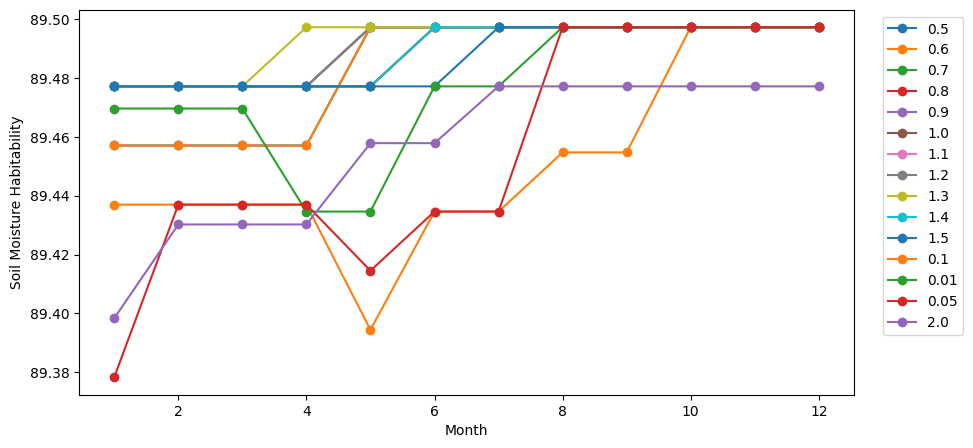

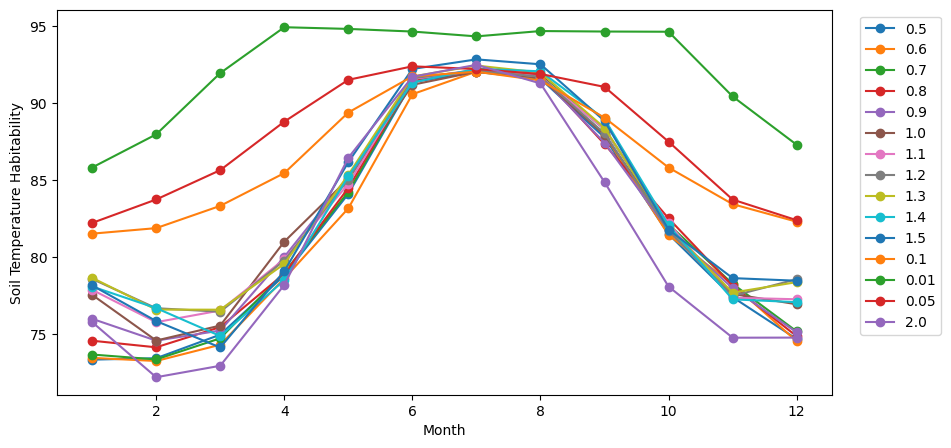

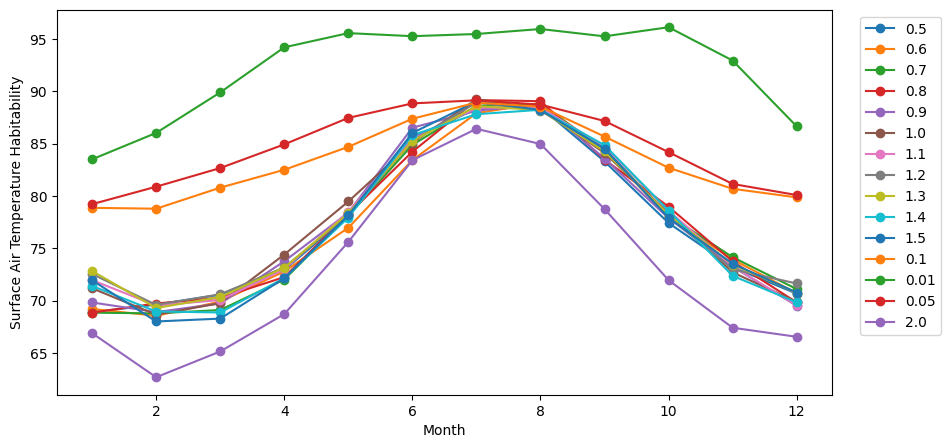

In [61]:
fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    sm = r["data"]["sm_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sm, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    st = r["data"]["st_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    st = r["data"]["tsurf_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Surface Air Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

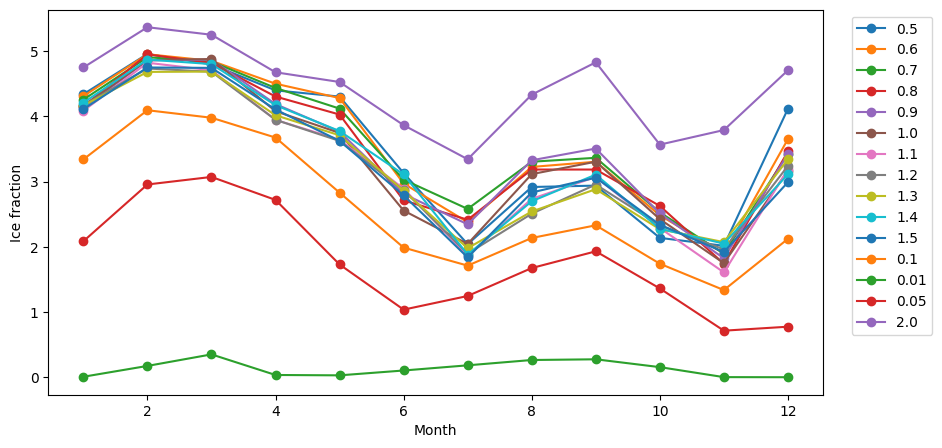

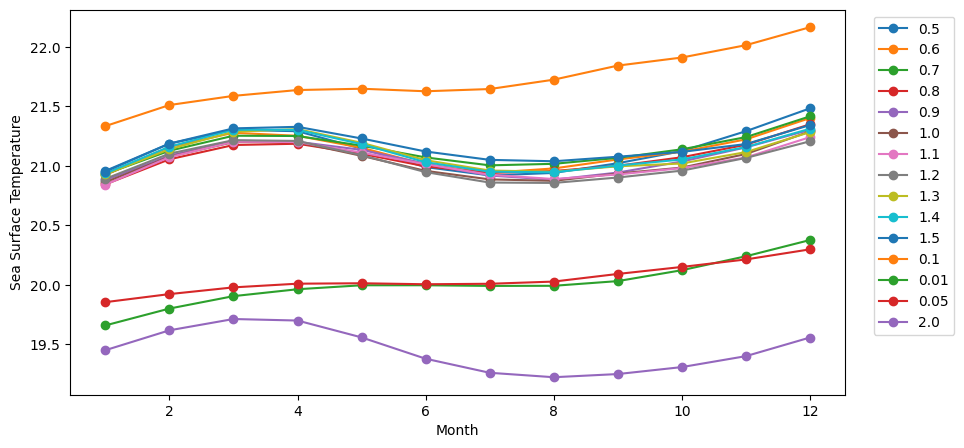

In [44]:
fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    ice = r["data"]["ice_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, ice, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Ice fraction")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    sst = r["data"]["sst_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sst, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

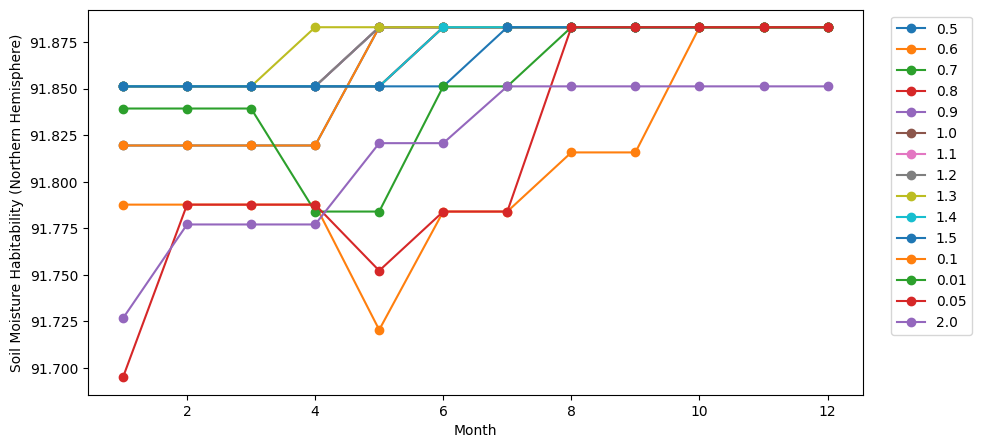

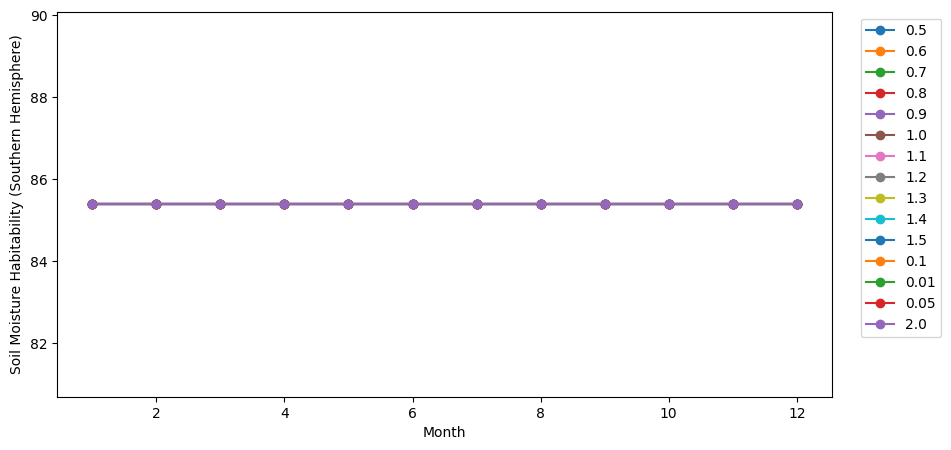

In [47]:
# Check habitability in different hemispheres for soil moisture 

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    sm = r["data"]["sm_nhem"]
    month = r["data"]["month"][0]
    plt.plot(month, sm, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    sm = r["data"]["sm_shem"]
    month = r["data"]["month"][0]
    # plt.plot(month, sm, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, sm, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

Check north and south hemisphere for soil temperature

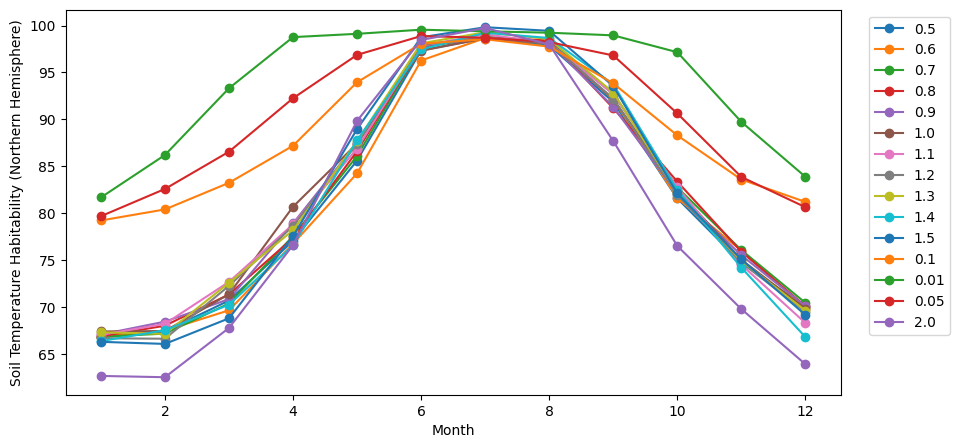

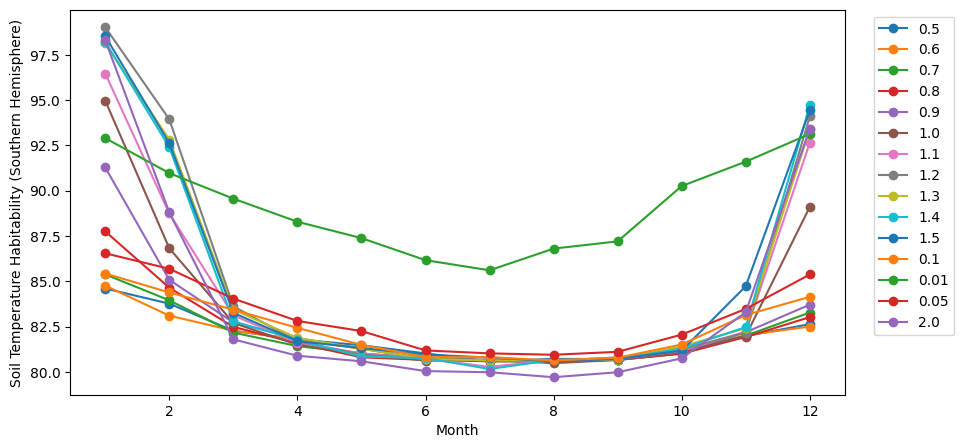

In [48]:
fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    st = r["data"]["st_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    st = r["data"]["st_shem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

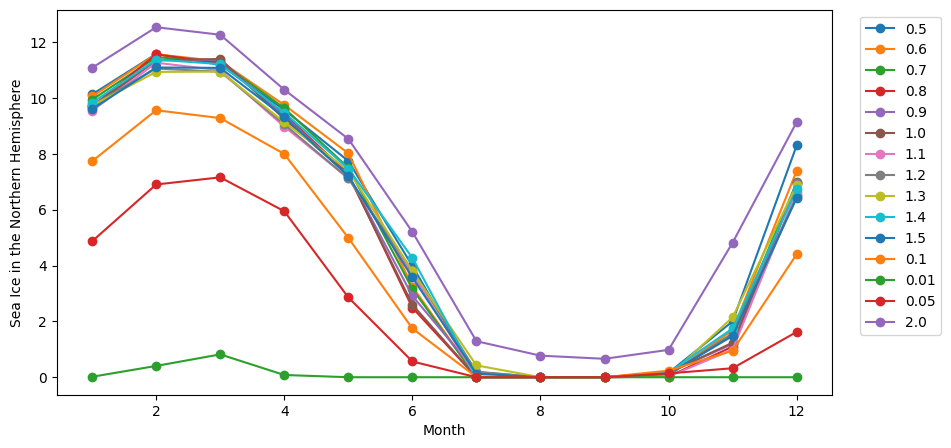

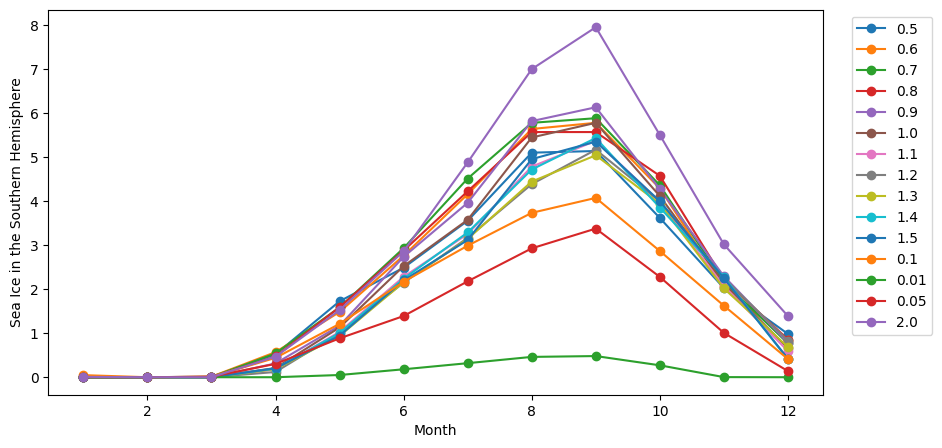

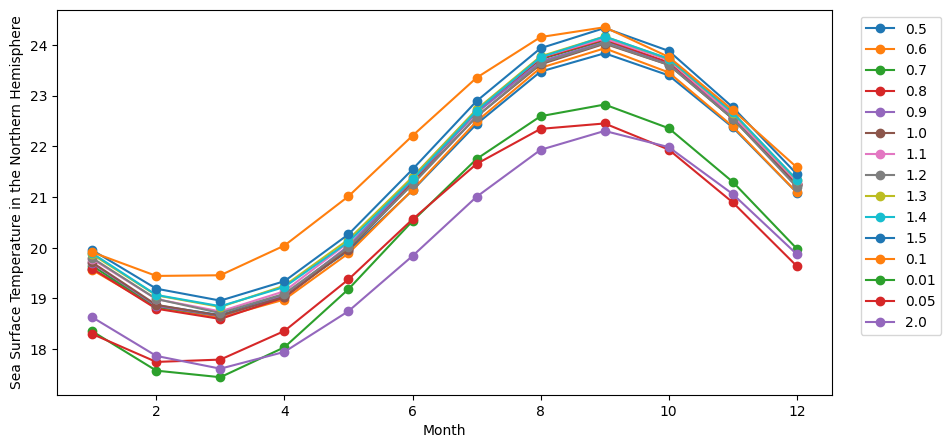

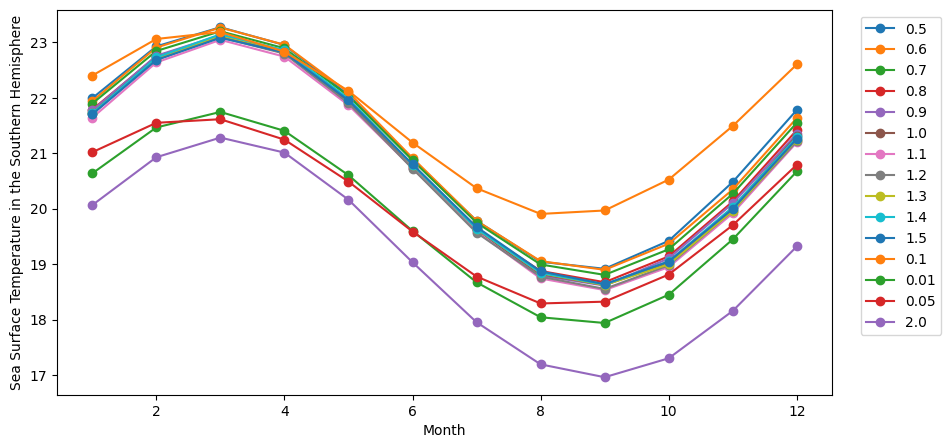

In [49]:
fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    st = r["data"]["ice_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Sea Ice in the Northern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    st = r["data"]["ice_shem"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Sea Ice in the Southern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    st = r["data"]["sst_nhem"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature in the Northern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    st = r["data"]["sst_shem"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature in the Southern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

See if there's a correlation between incoming solar flux and sea ice conc/SST/habitability

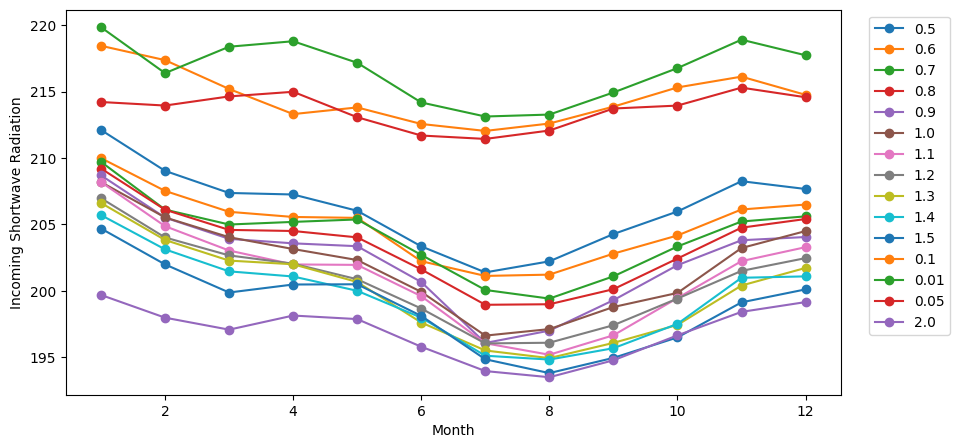

In [50]:
fig = plt.figure(figsize=(10, 5))
for r, rot in zip(results, rotation):
    srd = r["data"]["srd_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, srd, marker='o', label=f"{rot}")
plt.xlabel("Month")
plt.ylabel(f"Incoming Shortwave Radiation")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

In [64]:
# for r, rot in zip(results, rotation):
#     st = r["data"]["st_tot"]
#     tsurf = r["data"]["tsurf_tot"]
#     sm = r["data"]["sm_tot"]
#     srd = r["data"]["srd_tot"]
#     month = r["data"]["month"][0]

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     # First y-axis
#     ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
#     ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
#     ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
#     ax1.set_xlabel("Months")
#     ax1.set_ylabel("Habitability")


#     # Third y-axis (shares the same x-axis)
#     ax2 = ax1.twinx()
#     ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
#     ax2.set_ylabel("Shortwave Radiation")

#     fig.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
#     plt.tight_layout()
#     plt.title(f"Habitability and Shortwave Radiation for {rot}")
#     plt.show()

In [63]:
# for r, rot in zip(results, rotation):
#     st = r["data"]["st_nhem"]
#     tsurf = r["data"]["tsurf_nhem"]
#     sm = r["data"]["sm_nhem"]
#     srd = r["data"]["srd_nhem"]
#     month = r["data"]["month"][0]

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     # First y-axis
#     ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
#     ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
#     ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
#     ax1.set_xlabel("Months")
#     ax1.set_ylabel("Soil Moisture")


#     # Third y-axis (shares the same x-axis)
#     ax2 = ax1.twinx()
#     ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
#     ax2.set_ylabel("Shortwave Radiation")

#     fig.legend(loc="upper right")
#     plt.tight_layout()
#     plt.title(f"Habitability and Shortwave Radiation in the Northern Hemisphere for {rot}")
#     plt.show()

In [62]:
# for r, rot in zip(results, rotation):
#     st = r["data"]["st_shem"]
#     tsurf = r["data"]["tsurf_shem"]
#     sm = r["data"]["sm_shem"]
#     srd = r["data"]["srd_shem"]
#     month = r["data"]["month"][0]

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     # First y-axis
#     ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
#     ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
#     ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
#     ax1.set_xlabel("Months")
#     ax1.set_ylabel("Soil Moisture")


#     # Third y-axis (shares the same x-axis)
#     ax2 = ax1.twinx()
#     ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
#     ax2.set_ylabel("Shortwave Radiation")

#     fig.legend(loc="upper right")
#     plt.tight_layout()
#     plt.title(f"Habitability and Shortwave Radiation in the Southern Hemisphere for {rot}")
#     plt.show()